In [1]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares, curve_fit
from scipy.fft import fft, fftfreq
import matplotlib.pyplot as plt

O sistema de EDO que contém os parâmetros de interesse é

\begin{equation}
\begin{aligned}
    \frac{dn_5}{dt}
    &=
    \sigma P F(t)\, n_4
    - W_{51} n_1 n_5
    - W_{52} n_2 n_5
    - k_{54} n_5 
    \\
    \frac{dn_2}{dt}
    &=
    W_{51} n_1 n_5
    - W_{52} n_2 n_5
    - k_{21} n_2 
    \\
    \frac{dn_3}{dt}
    &=
    W_{52} n_2 n_5
    - k_{31} n_3 
\end{aligned}
\end{equation}

Adimensionalizando a concentração por $n_1$ e o tempo por $2\pi/\omega$, obtemos

\begin{aligned}
\frac{dx_5}{dt}
&=
\Pi F(\tau) x_4
- W'_{51} x_5
- W'_{52} x_2 x_5
- k'_{54} x_5
\\
\frac{dx_2}{dt}
&=
W'_{51} x_5
- W'_{52} x_2 x_5
- k'_{21} x_2
\\
\frac{dx_3}{dt}
&=
W'_{52} x_2 x_5
- k'_{31} x_3
\end{aligned},
onde 

### Dados experimentais

In [2]:
from treament_tcspc_data import fetch_data_filenames, extract_data_info_from_path, time_domain_visual_verification
# from snr_aux_functions import get_snr_db, plot_time_and_freq_domain

In [3]:
# filenames_all = fetch_data_filenames("./experimental_data/")
# # filenames_all = fetch_data_filenames("./23-05-26")
# exc_data_npy = [
#     extract_data_info_from_path(data_path_npy) for data_path_npy in filenames_all 
#     if ("step" in data_path_npy) and (".npy" in data_path_npy) and ("exc_laser" in data_path_npy)
#     ]

# #Populate particle list

# num_particles = 30
# p_list = [
#     {
#         "p_label": p_id+1,
#         "p_data": [
#             extract_data_info_from_path(p_data_path)
#             for p_data_path in filenames_all
#             if (f"p{p_id+1}_lum" in p_data_path) and ("step" in p_data_path) and (".npy" in p_data_path)
#         ]
#     }
#     for p_id in range(num_particles) if p_id == 12
# ]

# time_domain_visual_verification(p_list)

# print(data_test.shape)

# data_test = np.array([freq_data for freq_data in p_list[0]["p_data"] if freq_data["freq"] == 1000 ][0]["data"])

# plt.plot(
#     data_test[0,:,0],
#     data_test[:,:,1].mean(axis=0),
# )
# plt.ylabel("Counts")
# plt.xlabel("t ($\mu s$)")
# plt.show()


### Tentativa de parâmetros iniciais via eq. 18

In [7]:
#--------------------------------------
# Parâmetros inseridos
#--------------------------------------
sigma = 1.75e-20 # cm^2
P = 5.4e20  
n1 = 2.3e20 #população de Er3+ (cm^-3)
n4 = 1.3e21
k54 = 1279.0

#--------------------------------------
#Ajustado via eq. (18)
#--------------------------------------
k31  = 24133.48
kp5  = 193625318602.30
kp21 = 7063.64
r     = 0.4620

print(50*"=")
print("Taxas de decaimentos radiativos:")
print(f"k21 = {(r*kp21):.5}")
print(f"k31 = {(k31):.5}")
print(50*"=")
print("Taxas de decaimentos não radiativos:")
print(f"W51 = {((kp5-k54)/n1):.5}")
print(f"W52 = {(kp5*kp21*(1-r)/(sigma*P*n4)):.5}")
print(50*"=")

Taxas de decaimentos radiativos:
k21 = 3263.4
k31 = 2.4133e+04
Taxas de decaimentos não radiativos:
W51 = 8.4185e-10
W52 = 5.9896e-08


### Simulação

In [ ]:
# 1. Constantes Físicas (Valores consolidados para Y2O3)
#====================================================
# Constantes depois do ajuste de eq. 18
#====================================================
k21 = 3263.4 #16.66   # s^-1
k31 = 2.4133e+04 #192.0   # s^-1
ww51 = 8.4185e-10
ww52 = 5.9896e-08
#====================================================

#====================================================
# A partir do artigo de Labrador (https://doi.org/10.1021/acs.jpclett.3c00269) 
#====================================================
n1 = 2.3e20 # Supporting Information, page S5, Labrador
n4 = 1.3e21 # Supporting Information, page S5, Labrador
k54 = 1279.0  # Tab. 2 Lu0 em https://doi.org/10.1016/j.jallcom.2021.159227
sigma = 1.75e-20 # # Supporting Information, page S5, Labrador
P = 5.4e20    # fótons / (cm^2 * s) (baseado em 110 W/cm^2)
# usados antes
# n1 = 2.3e20 #população de Er3+ (cm^-3)
# n4 = 1.3e21 #população de Yb3+ (cm^-3)
# k54 = 1279.0  # s^-1
# k31 = 192.0   # s^-1
# k21 = 16.66   # s^-1
# sigma = 1.75e-20 # cm^2
# P = 5.4e20    # fótons / (cm^2 * s) (baseado em 110 W/cm^2)


#====================================================
# Dados de meus experimentos
#====================================================
amplitude = 0.5
offset = 0.8
#====================================================

# Ajustando novos parâmetros
wp51 = lambda omega, W51: 2*np.pi*W51*n1/omega
wp52 = lambda omega, W52: 2*np.pi*W52*n1/omega
kp21 = lambda omega: 2*np.pi*k21/omega
kp31 = lambda omega: 2*np.pi*k31/omega
kp45 = lambda omega: 2*np.pi*sigma*P/omega
kp54 = lambda omega: 2*np.pi*k54/omega
x4 = n4/n1

# Diferença de fase experimental freq, ph_diff, error_pd
# Exemplo com 3 frequências extraídas da sua Figura 12
# pd = np.array([[ 1.00000000e+00, -2.78640057e-03,  3.36729982e-03],
#        [ 2.00000000e+00, -2.94542499e-03,  3.30445647e-03],
#        [ 3.00000000e+00, -5.70062310e-03,  2.22292791e-03],
#        [ 5.00000000e+00, -1.15347657e-03,  3.38780739e-03],
#        [ 7.00000000e+00, -1.14123889e-02,  3.33181254e-03],
#        [ 1.00000000e+01, -7.57860157e-03,  3.31657015e-03],
#        [ 2.00000000e+01, -1.25420350e-02,  3.19388745e-03],
#        [ 3.00000000e+01, -1.16159364e-02,  3.66126559e-03],
#        [ 5.00000000e+01, -2.39443326e-02,  3.09906367e-03],
#        [ 7.00000000e+01, -3.15226287e-02,  2.85755006e-03],
#        [ 1.00000000e+02, -5.28665836e-02,  3.35273380e-03],
#        [ 2.00000000e+02, -8.30688285e-02,  2.73059639e-03],
#        [ 3.00000000e+02, -1.33267253e-01,  4.03296653e-03],
#        [ 5.00000000e+02, -2.24394939e-01,  3.47703795e-03],
#        [ 7.00000000e+02, -3.65668758e-01,  3.51463917e-03],
#        [ 1.00000000e+03, -4.71239925e-01,  3.47630975e-03],
#        [ 2.00000000e+03, -6.40636375e-01,  3.75070348e-03],
#        [ 3.00000000e+03, -8.06144725e-01,  3.44250145e-03],
#        [ 5.00000000e+03, -9.67168365e-01,  2.84889823e-03],
#        [ 7.00000000e+03, -1.18290875e+00,  3.72268580e-03],
#        [ 1.00000000e+04, -1.34746600e+00,  4.92232407e-03],
#        [ 2.00000000e+04, -1.40335577e+00,  8.13990120e-03],
#        [ 3.00000000e+04, -1.48759587e+00,  1.57209815e-02],
#        [ 5.00000000e+04, -1.34833651e+00,  2.13302156e-02],
#        [ 7.00000000e+04, -1.28640332e+00,  3.61040996e-02],
#        [ 1.00000000e+05, -1.23208184e+00,  6.92253145e-02]])

In [9]:
print([
    wp51(2*np.pi*1000, 1e-10),
    wp52(2*np.pi*1000, 1e-10),
    kp21(2*np.pi*1000),
    kp31(2*np.pi*1000),
    kp45(2*np.pi*1000),
    kp54(2*np.pi*1000),
    x4])

[23000000.000000004, 23000000.000000004, 3.2634000000000003, 24.133000000000003, 0.00945, 1.2790000000000001, 5.6521739130434785]


In [10]:
def odes(t, x, W51, W52, freq):
    # o t agora é tau
    x5, x2, x3 = x
    omega = 2 * np.pi * freq
    
    # Função do laser conforme seus dados experimentais
    F_t = offset + amplitude * np.cos(2*np.pi * t)
    
    # Prevenção numérica: a intensidade não pode ser negativa
    if F_t < 0: F_t = 0.0 
    
    dx5_dt = kp45(omega) * F_t * x4 - wp51(omega, W51) * x5 - wp52(omega, W52) * x2 * x5 - kp54(omega) * x5
    dx2_dt = wp51(omega, W51) * x5 - wp52(omega, W52) * x2 * x5 - kp21(omega) * x2
    dx3_dt = wp52(omega, W52) * x2 * x5 - kp31(omega) * x3
    
    return [dx5_dt, dx2_dt, dx3_dt]

In [11]:
# f=1000
# t_span = (0, 200) # Simula alguns ciclos

# x0 = [0, 0, 0]

# t_eval = np.linspace(t_span[0], t_span[-1], 1000)

# ww51 = w_list[0] 
# ww52 = w_list[1] 

# sol_1kHz = solve_ivp(
#     odes, 
#     t_span, 
#     x0, 
#     t_eval=t_eval,
#     args=(ww51, ww52, f),
#     # method="BDF",
#     method="Radau",
#     )

# plt.plot((1/f)*(sol_1kHz.t), (sol_1kHz.y[0])*n1, "blue", label="$n_5(t)$")
# plt.plot((1/f)*(sol_1kHz.t), (sol_1kHz.y[1])*n1, "red" ,label="$n_2(t)$")
# plt.plot((1/f)*(sol_1kHz.t), (sol_1kHz.y[2])*n1, "green" ,label="$n_3(t)$")
# plt.title(f"Populations at {f}Hz -" + f" W51={ww51:.2} - W52={ww52:.2}")
# plt.legend(loc="best")

# plt.tight_layout()
# plt.show()


In [12]:
# 3. Função para Extrair a Fase via FFT
def extrair_fase(t, n3, freq):
    # DICA CRUCIAL: Descartar a primeira metade da simulação (o transiente)
    # Analisamos apenas a parte onde a onda já estabilizou
    meio = len(t) // 2
    t_estavel = t[meio:]
    n3_estavel = n3[meio:]
    
    # Recria o sinal do laser no mesmo intervalo de tempo para comparação
    laser_estavel = offset + amplitude * np.cos(2 * np.pi * freq * t_estavel)
    
    N = len(t_estavel)
    dt = t_estavel[1] - t_estavel[0]
    
    # Aplica a FFT
    yf_n3 = fft(n3_estavel)
    yf_laser = fft(laser_estavel)
    xf = fftfreq(N, dt)
    
    # Encontra o índice da frequência de modulação (freq) no array da FFT
    idx = np.argmin(np.abs(xf - freq))
    
    # Extrai o ângulo (fase) de ambos os sinais nesse pico de frequência
    fase_n3 = np.angle(yf_n3[idx])
    fase_laser = np.angle(yf_laser[idx])
    
    # Diferença de fase (Luminescência - Laser)
    delta_fase = fase_n3 - fase_laser
    
    # Garante que o valor fique no intervalo correto [-pi, pi]
    delta_fase = np.angle(np.exp(1j * delta_fase))
    
    return delta_fase

Processing W51=8.4e-10 and W52=8.4e-10 | Depois dos ajustes: W51 = 8.4185e-10 W52 = 5.9896e-08


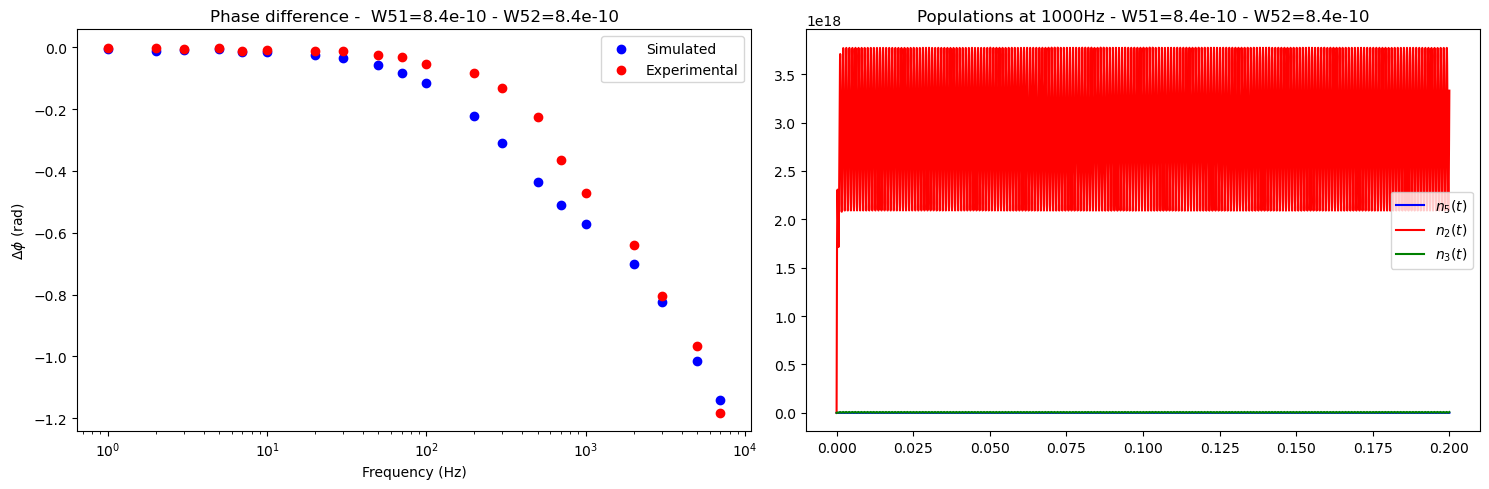

Processing W51=8.4e-10 and W52=6e-08 | Depois dos ajustes: W51 = 8.4185e-10 W52 = 5.9896e-08


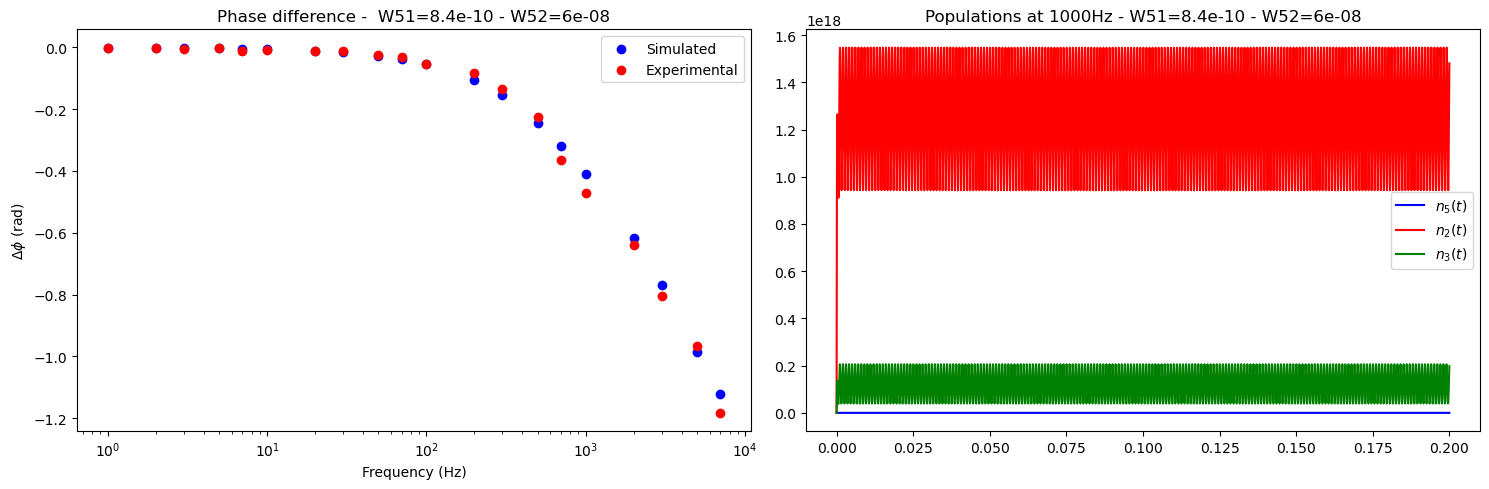

Processing W51=6e-08 and W52=8.4e-10 | Depois dos ajustes: W51 = 8.4185e-10 W52 = 5.9896e-08


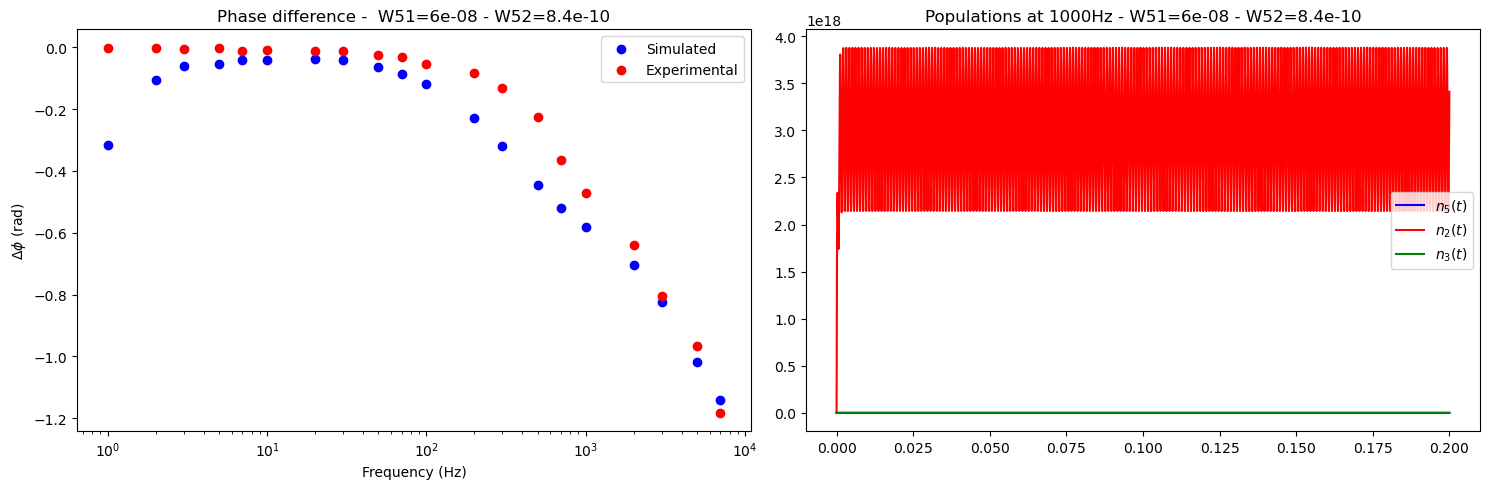

Processing W51=6e-08 and W52=6e-08 | Depois dos ajustes: W51 = 8.4185e-10 W52 = 5.9896e-08


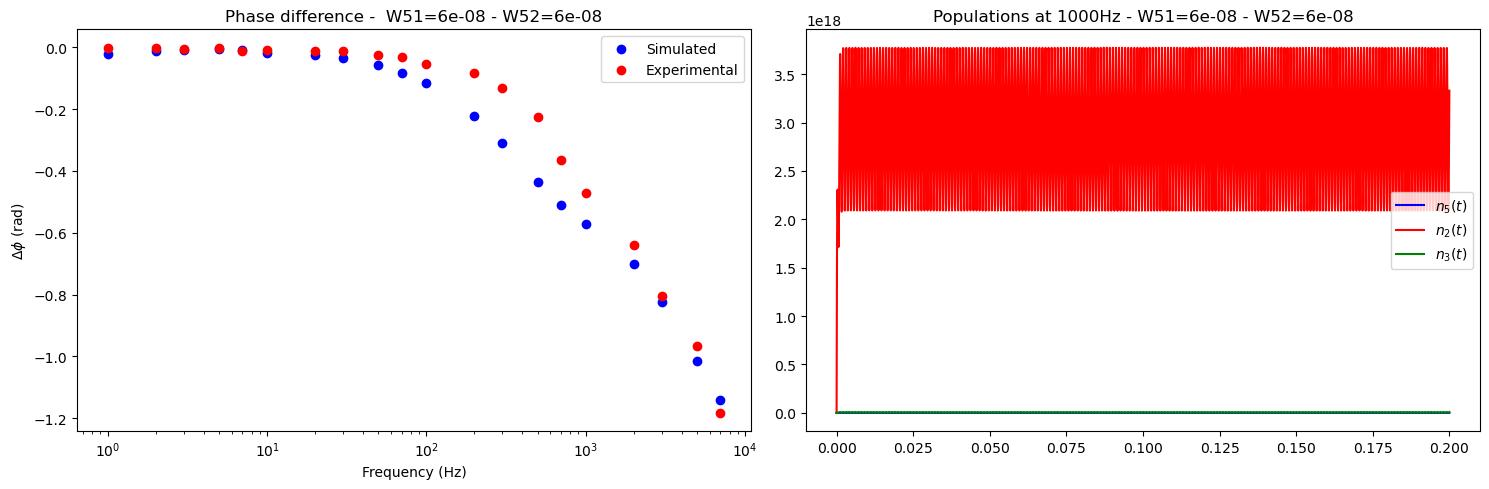

In [13]:
for ww51 in w_list:
    for ww52 in w_list:
        print("==================================================")
        print(f"Processing W51={ww51:.2} and W52={ww52:.2} | Depois dos ajustes: W51 = 8.4185e-10 W52 = 5.9896e-08") 
        print("==================================================")
        pd_simulated = []
        num_points = 20 #len(pd)

        for freq in pd[:num_points,0]:
            # if freq != 1000: continue

            #define as EDOS
            def odes(t, x, W51, W52, freq):
             # o t agora é tau
             x5, x2, x3 = x
             omega = 2 * np.pi * freq

             # Função do laser conforme seus dados experimentais
             F_t = offset + amplitude * np.cos(2*np.pi * t)

             # Prevenção numérica: a intensidade não pode ser negativa
             if F_t < 0: F_t = 0.0 

             dx5_dt = kp45(omega) * F_t * x4 - wp51(omega, W51) * x5 - wp52(omega, W52) * x2 * x5 - kp54(omega) * x5
             dx2_dt = wp51(omega, W51) * x5 - wp52(omega, W52) * x2 * x5 - kp21(omega) * x2
             dx3_dt = wp52(omega, W52) * x2 * x5 - kp31(omega) * x3

             return [dx5_dt, dx2_dt, dx3_dt]

            t_span = (0, 200) # Simula 200 ciclos
            #ww51 = w_list[0]
            #ww52 = w_list[1]
            x0 = [0, 0, 0]

            t_eval = np.linspace(t_span[0], t_span[-1], 10000)

            sol = solve_ivp(
                odes, 
                t_span, 
                x0, 
                t_eval=t_eval,
                args=(ww51, ww52, freq),
                method="Radau"
                )

            n3 = (sol.y[2])*n1
            ts = (sol.t)*(1/freq)

            pd_simulated.append(
                [freq, extrair_fase(ts, n3, freq)]
                )

        pd_simulated = np.array(pd_simulated)

        ## Fazer plots
        _, axs = plt.subplots(1,2, figsize=(15,5))

        axs[0].scatter(pd_simulated[:,0], np.unwrap(pd_simulated[:,1]), color="blue", label="Simulated")
        axs[0].scatter(pd[:num_points,0], pd[:num_points,1], color="red", label="Experimental")
        axs[0].set_title("Phase difference - " + f" W51={ww51:.2} - W52={ww52:.2}")
        axs[0].set_ylabel("$\Delta \phi$ (rad)")
        axs[0].set_xlabel("Frequency (Hz)")
        axs[0].set_xscale("log")
        axs[0].legend(loc="best")
        # plt.legend()

        # Plot para 1kHz
        f=1000
        t_span = (0, 200) # Simula 200 ciclos

        x0 = [0, 0, 0]

        t_eval = np.linspace(t_span[0], t_span[-1], 10000)

        sol_1kHz = solve_ivp(
            odes, 
            t_span, 
            x0, 
            t_eval=t_eval,
            args=(ww51, ww52, f),
            # method="BDF",
            method="Radau",
            )

        axs[1].plot((1/f)*(sol_1kHz.t), (sol_1kHz.y[0])*n1, "blue", label="$n_5(t)$")
        axs[1].plot((1/f)*(sol_1kHz.t), (sol_1kHz.y[1])*n1, "red" ,label="$n_2(t)$")
        axs[1].plot((1/f)*(sol_1kHz.t), (sol_1kHz.y[2])*n1, "green" ,label="$n_3(t)$")
        axs[1].set_title(f"Populations at {f}Hz -" + f" W51={ww51:.2} - W52={ww52:.2}")
        axs[1].legend(loc="best")

        plt.tight_layout()
        plt.show()


### Ajuste numérico

In [14]:
*****
# 4. Função Residual para o Otimizador
def funcao_custo(parametros, freq_exp, fase_exp):
    W51, W52 = parametros
    fases_calculadas = []
    
    # Penalidade severa se o otimizador tentar testar valores negativos para W
    if W51 < 0 or W52 < 0:
        return np.ones_like(fase_exp) * 1e6
        
    for f in freq_exp:
        t_span = (0, 1/f * 20) # 20 ciclos garante que o transiente morra
        t_eval = np.linspace(t_span[0], t_span[1], 2000)
        
        sol = solve_ivp(
            odes, t_span, [0, 0, 0], 
            args=(W51, W52, f), 
            method='BDF', t_eval=t_eval, rtol=1e-6, atol=1e-9
        )
        
        # Pega a população de n3 (índice 2)
        n3 = sol.y[2]
        
        fase_calc = extrair_fase(sol.t, n3, f)
        fases_calculadas.append(fase_calc)
        
    fases_calculadas = np.array(fases_calculadas)
    
    # O Least Squares tentará minimizar essa diferença
    return fases_calculadas - fase_exp

# =====================================================================
# 5. EXECUÇÃO DO AJUSTE (Insira seus arrays aqui)
# =====================================================================



frequencias_experimentais = pd[:10,0] 
fases_experimentais = pd[:10,1] # Substitua pelos radianos exatos

# Palpite inicial para W51 e W52 (em cm^3 / s)
chute_inicial = [1e-17, 1e-17]

print("Iniciando ajuste numérico. Isso pode levar alguns minutos...")

# Roda o otimizador (pode usar bounds=(0, np.inf) se preferir em vez da penalidade manual)
# resultado = least_squares(
    funcao_custo, 
    chute_inicial, 
    args=(frequencias_experimentais, fases_experimentais),
    bounds=(0, np.inf), # Força valores positivos
    method='trf'
)

print("-" * 30)
print("AJUSTE CONCLUÍDO!")
print(f"W51 encontrado = {resultado.x[0]:.2e} cm³/s")
print(f"W52 encontrado = {resultado.x[1]:.2e} cm³/s")

SyntaxError: unmatched ')' (2684824657.py, line 53)